In [82]:
import osmnx as ox
import matplotlib.pyplot as plt
import geopandas
import networkx as nx
from shapely.geometry import box

In [16]:
place_graph = ox.graph_from_address("-23.543255, -46.642402", dist=1000, network_type="drive")

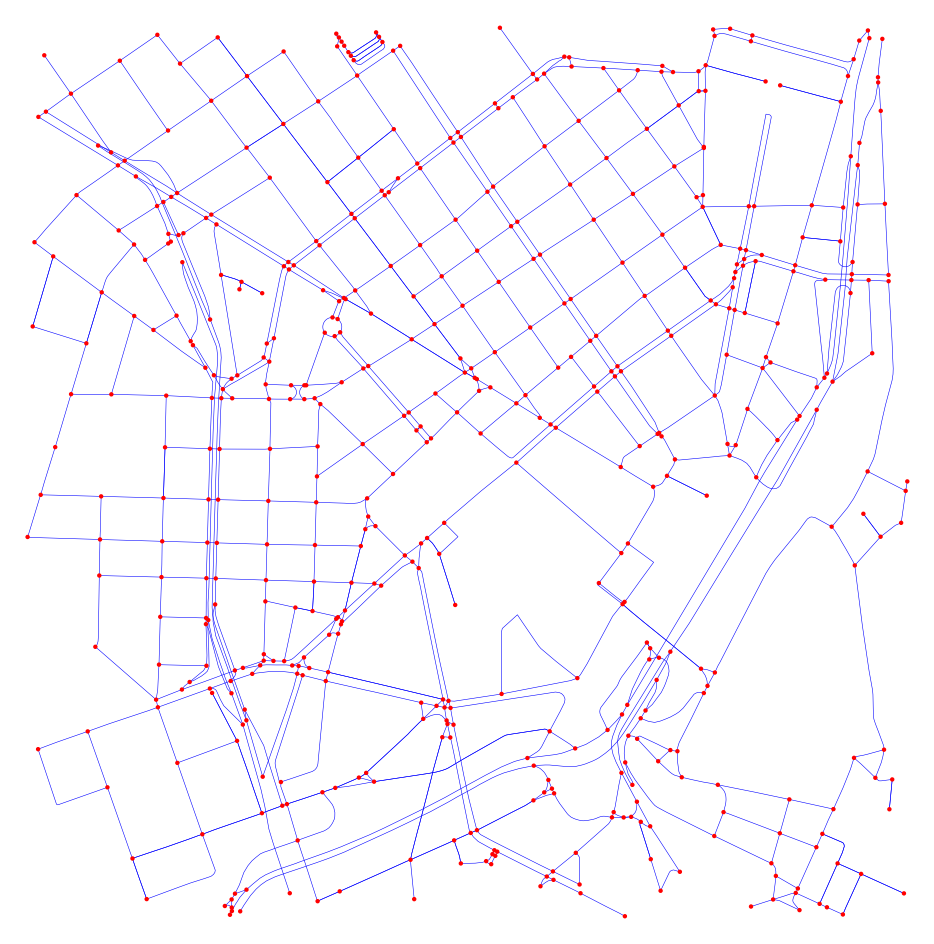

(<Figure size 1200x1200 with 1 Axes>, <Axes: >)

In [26]:
ox.plot_graph(place_graph, bgcolor="white", node_size=10, edge_color="blue", node_color="red", edge_linewidth=0.4, figsize=(12, 12), dpi=300)

In [38]:
gdf = ox.graph_to_gdfs(place_graph, edges=True, nodes=False)

In [41]:
features = geopandas.GeoDataFrame.from_features(gdf)
features.head()

,geometry,osmid,highway,name,oneway,reversed,length,lanes,maxspeed,bridge,tunnel,width,access,junction
0,"LINESTRING (-46.65132 -23.53889, -46.65133 -23...",8307075,residential,Rua Fortunato,False,False,164.142379,None,None,NaN,NaN,NaN,NaN,NaN
1,"LINESTRING (-46.65132 -23.53889, -46.65119 -23...",914039011,tertiary,Rua Frederico Abranches,True,False,135.690412,2,None,NaN,NaN,NaN,NaN,NaN
2,"LINESTRING (-46.65178 -23.54031, -46.65176 -23...",8307075,residential,Rua Fortunato,False,True,164.142379,None,None,NaN,NaN,NaN,NaN,NaN
3,"LINESTRING (-46.63379 -23.53525, -46.6338 -23....","[191591089, 866553011, 191591092]",secondary,Rua Brigadeiro Tobias,True,False,60.001610,3,50,yes,NaN,NaN,NaN,NaN
4,"LINESTRING (-46.63313 -23.53527, -46.6331 -23....",191591086,secondary,Avenida Tiradentes,True,False,86.895016,4,50,NaN,NaN,NaN,NaN,NaN


In [42]:
features.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 930 entries, 0 to 929
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   geometry  930 non-null    geometry
 1   osmid     930 non-null    object  
 2   highway   930 non-null    object  
 3   name      884 non-null    object  
 4   oneway    930 non-null    bool    
 5   reversed  930 non-null    object  
 6   length    930 non-null    float64 
 7   lanes     726 non-null    object  
 8   maxspeed  384 non-null    object  
 9   bridge    26 non-null     str     
 10  tunnel    17 non-null     str     
 11  width     5 non-null      str     
 12  access    20 non-null     str     
 13  junction  5 non-null      str     
dtypes: bool(1), float64(1), geometry(1), object(6), str(5)
memory usage: 95.5+ KB


In [43]:
features["maxspeed"].value_counts()

maxspeed
40          194
50          155
30           12
20            9
[30, 40]      5
60            4
[50, 40]      3
[50, 60]      1
[30, 20]      1
Name: count, dtype: int64

In [49]:
# print min, max, mean, median of length
print("Min length:", features['length'].min()//1, "meters")
print("Max length:", features['length'].max()//1, "meters")
print("Mean length:", features['length'].mean()//1, "meters")
print("Median length:", features['length'].median()//1, "meters")
print("Total length:", features['length'].sum()//1, "meters")

Min length: 2.0 meters
Max length: 893.0 meters
Mean length: 90.0 meters
Median length: 79.0 meters
Total length: 84116.0 meters


In [53]:
graph_proj = ox.project_graph(place_graph)

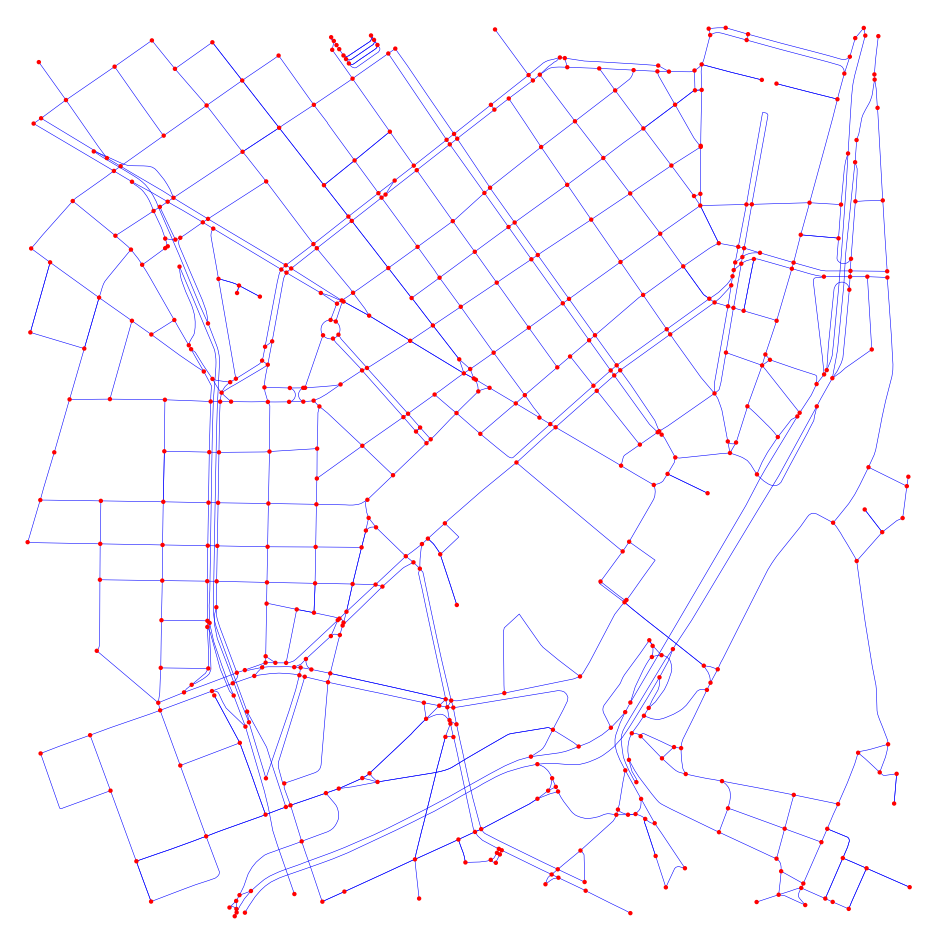

(<Figure size 1200x1200 with 1 Axes>, <Axes: >)

In [54]:
ox.plot_graph(graph_proj, bgcolor="white", node_size=10, edge_color="blue", node_color="red", edge_linewidth=0.4, figsize=(12, 12), dpi=300)

In [55]:
nod_proj, edg_proj = ox.graph_to_gdfs(graph_proj, nodes=True, edges=True)

In [56]:
edg_proj.crs

<Projected CRS: EPSG:32723>
Name: WGS 84 / UTM zone 23S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 48°W and 42°W, southern hemisphere between 80°S and equator, onshore and offshore. Brazil.
- bounds: (-48.0, -80.0, -42.0, 0.0)
Coordinate Operation:
- name: UTM zone 23S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [57]:
edg_proj.head()

osmid      highway                     name  \
u         v          key                                                    
20944551  20944552   0      8307075  residential            Rua Fortunato   
          158844513  0    914039011     tertiary  Rua Frederico Abranches   
20944552  20944551   0      8307075  residential            Rua Fortunato   
158844513 298937045  0    329263858     tertiary       Rua Dona Veridiana   
          1849075704 0    929414411     tertiary  Rua Frederico Abranches   

                          oneway reversed      length  \
u         v          key                                
20944551  20944552   0     False    False  164.142379   
          158844513  0      True    False  135.690412   
20944552  20944551   0     False     True  164.142379   
158844513 298937045  0     False     True  119.835229   
          1849075704 0      True    False   90.455199   

                                                                   geometry  \
u         v          key                                                      
20944551  20944552   0    LINESTRING (331433.167 7395852.476, 331432.354...   
          158844513  0    LINESTRING (331433.167 7395852.476, 331447.057...   
20944552  20944551   0    LINESTRING (331388.784 7395695.06, 331390.687 ...   
158844513 298937045  0    LINESTRING (331543.298 7395773.303, 331542.512...   
          1849075704 0    LINESTRING (331543.298 7395773.303, 331554.983...   

                         lanes maxspeed bridge tunnel width access junction  
u         v          key                                                     
20944551  20944552   0     NaN      NaN    NaN    NaN   NaN    NaN      NaN  
          158844513  0       2      NaN    NaN    NaN   NaN    NaN      NaN  
20944552  20944551   0     NaN      NaN    NaN    NaN   NaN    NaN      NaN  
158844513 298937045  0       2      NaN    NaN    NaN   NaN    NaN      NaN  
          1849075704 0       1      NaN    NaN    NaN   NaN    NaN      NaN

In [85]:
# criar método para buscar primeiro registro por nome
def get_edge_by_name(name):
    return edg_proj[edg_proj['name'] == name].iloc[0]

def get_node_by_edge(edge):
    bbox = box(*edge.geometry.bounds)
    nearest_node = nod_proj[nod_proj.geometry.within(bbox)].iloc[0]
    return nearest_node
    

In [89]:
edge = get_edge_by_name("Praça da República")
print(edge)

osmid                                               662540606
highway                                             secondary
name                                       Praça da República
oneway                                                   True
reversed                                                False
length                                              211.38247
geometry    LINESTRING (332481.57805012236 7395402.5808668...
lanes                                                       5
maxspeed                                                   40
bridge                                                    NaN
tunnel                                                    NaN
width                                                     NaN
access                                                    NaN
junction                                                  NaN
Name: (60685763, 60685761, 0), dtype: object


In [ ]:
orig_node = get_node_by_edge(get_edge_by_name("Praça da República"))
dest_node = get_node_by_edge(get_edge_by_name("Rua Dona Veridiana"))

In [88]:
node0 = nod_proj.iloc[0]
print(node0)

y                                          7395852.47604
x                                          331433.166877
street_count                                           3
highway                                              NaN
ref                                                  NaN
geometry        POINT (331433.1668766 7395852.476039754)
Name: 20944551, dtype: object


In [ ]:
def node_within_polygon(node_row, polygon):
    return node_row.geometry.within(polygon)

# Exemplo de uso:
# edge = get_edge_by_name("Praça da República")
nodes_within = nod_proj[nod_proj.apply(node_within_polygon, args=(edge.geometry,), axis=1)]
print(nodes_within.head())

Empty GeoDataFrame
Columns: [y, x, street_count, highway, ref, geometry]
Index: []


In [ ]:
print(bbox)
print(bbox.contains(orig_node.geometry))

POLYGON ((332481.57805012236 7395265.8518258985, 332481.57805012236 7395402.5808668425, 332320.62751353113 7395402.5808668425, 332320.62751353113 7395265.8518258985, 332481.57805012236 7395265.8518258985))


In [ ]:
bbox = box(*edge.geometry.bounds)
nearest_node = nod_proj[nod_proj.geometry.within(bbox)].iloc[0]

In [58]:
nod_proj.head()

,y,x,street_count,highway,ref,geometry
osmid,,,,,,
20944551,7.395852e+06,331433.166877,3,NaN,NaN,POINT (331433.167 7395852.476)
20944552,7.395695e+06,331388.783998,4,NaN,NaN,POINT (331388.784 7395695.06)
158844513,7.395773e+06,331543.297670,4,traffic_signals,NaN,POINT (331543.298 7395773.303)
25928438,7.396277e+06,333218.626381,3,NaN,NaN,POINT (333218.626 7396276.883)
2021790380,7.396219e+06,333203.119264,3,traffic_signals,NaN,POINT (333203.119 7396219.148)


In [110]:
# faça um laço randomico de 0 a 5
import random
random_nodes = random.sample(list(graph_proj.nodes()), 5)

In [ ]:
def calculate_weight(d):
    length = d.get('length') # em metros
    maxspeed = d.get('maxspeed', 50) # em km/h
    # Se for lista, pega o menor valor e converte para float
    if isinstance(maxspeed, list):
        maxspeed = min([float(x) for x in maxspeed if str(x).replace('.', '', 1).isdigit()])
    # Se for string, converte para float
    elif isinstance(maxspeed, str):
        if maxspeed.replace('.', '', 1).isdigit():
            maxspeed = float(maxspeed)
        else:
            maxspeed = 50  # valor padrão se não for número
    # Se não, tenta converter para float
    else:
        maxspeed = float(maxspeed)
    # Redução: quanto menor o length, maior a redução de velocidade
    # Exemplo: redução de até 50% para ruas curtas (<50m)
    reduction_factor = 1 - min(0.5, 50 / max(length, 1) * 0.5)  # ajuste conforme necessário
    adjusted_speed = maxspeed * reduction_factor
    return length/(max(adjusted_speed, 1) * 1000 / 3600) # tempo = distancia / velocidade em segundos

def weight_function(u, v, d):
    """Calcula o peso de uma aresta usando length e maxspeed, com redução para ruas curtas."""
    weight = []
    # se d é um dicionario de dicionarios, precisamos efetuar o calculo para cada subdicionario
    if isinstance(d, dict):
        # se for um dicionario de dicionarios, precisamos iterar sobre os subdicionarios
        for key in d:
            sub_d = d[key]
            weight.append(calculate_weight(sub_d)) # tempo = distancia / velocidade
    # se d é um dicionario simples, podemos efetuar o calculo diretamente
    else:
        weight.append(calculate_weight(d)) # tempo = distancia / velocidade
    return sum(weight)/len(weight) # calcular o tempo médio

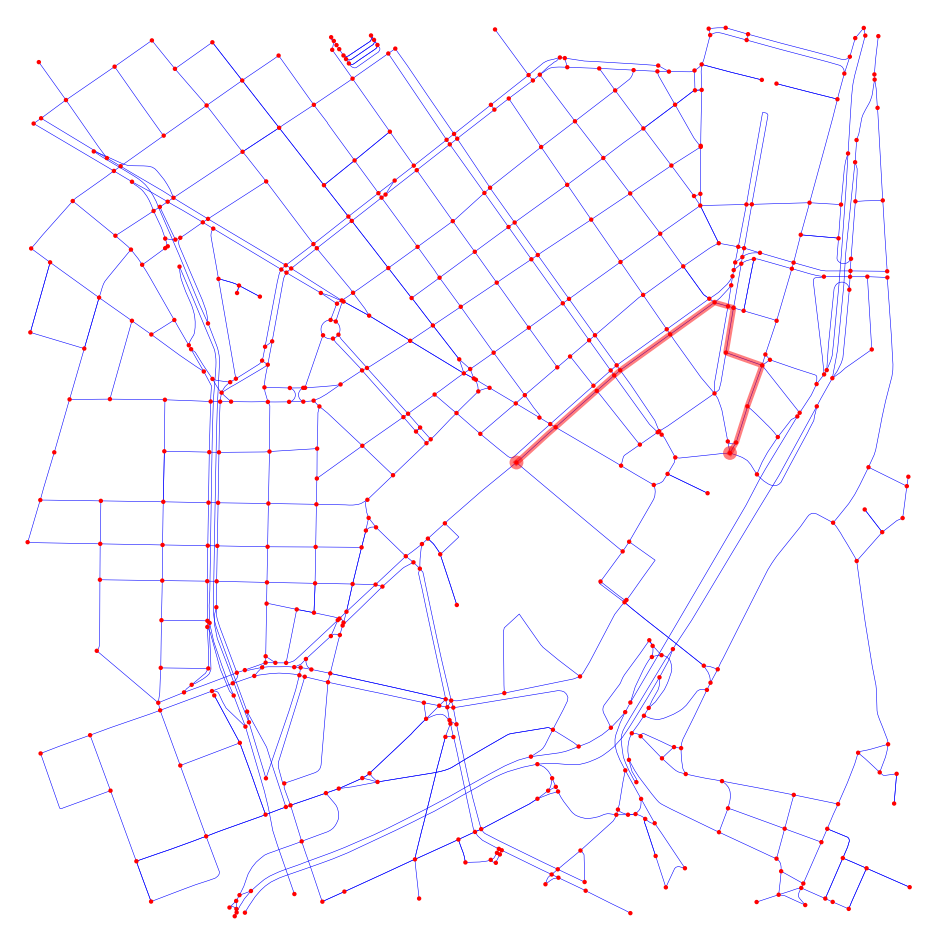

In [156]:
route = nx.shortest_path(graph_proj, random_nodes[1], random_nodes[2], weight=weight_function)
fig, ax = ox.plot_graph_route(graph_proj, route, bgcolor="white", node_size=10, edge_color="blue", node_color="red", edge_linewidth=0.4, figsize=(12, 12), dpi=300)

In [175]:
def path_weight_sum(graph, path, weight='length'):
    total = 0
    for u, v in zip(path[:-1], path[1:]):
        edge_data = graph.get_edge_data(u, v)
        if isinstance(edge_data, dict):
            # Caso haja múltiplas arestas, pega a primeira
            edge = list(edge_data.values())[0]
        else:
            edge = edge_data
        total += edge.get(weight, 0)
    return total

In [187]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_route_with_eta(graph, route, weight_function):
    total_eta = 0
    total_length = 0

    # Gera cores diferentes para cada segmento
    num_segments = len(route)
    colors = plt.get_cmap('tab10', num_segments)

    fig, ax = ox.plot_graph(graph, bgcolor="white", node_size=10, edge_color="gray", node_color="red", edge_linewidth=0.4, figsize=(12, 12), dpi=300, show=False, close=False)

    for i in range(num_segments):
        start = route[i]
        end = route[(i + 1) % num_segments]  # fecha o ciclo
        eta, segment = nx.bidirectional_dijkstra(graph, start, end, weight=weight_function)
        length = path_weight_sum(graph, segment)
        total_eta += eta
        total_length += length
        color = mcolors.to_hex(colors(i))
        # Plota o segmento
        ox.plot_graph_route(
            graph, segment, route_color=color, route_linewidth=3,
            ax=ax, orig_dest_node_color='none', show=False, close=False
        )
        # Pega o ponto do meio do segmento para a legenda
        mid_idx = len(segment) // 2
        mid_node = segment[mid_idx]
        x = graph.nodes[mid_node]['x']
        y = graph.nodes[mid_node]['y']
        ax.text(x, y, f"{eta/60:.1f} min - {length:.1f} m", color=color, fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

    # Cria legenda
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color=mcolors.to_hex(colors(i)), lw=3, label=f"Segmento {i+1}") for i in range(num_segments)
    ]
    ax.legend(handles=legend_elements, loc='best')
    # Adiciona total ETA e total length no canto superior esquerdo
    ax.text(
        0.01, 0.99,
        f"ETA total: {total_eta/60:.1f} min\nLength total: {total_length:.1f} m",
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(facecolor='white', alpha=0.8)
    )
    plt.show()

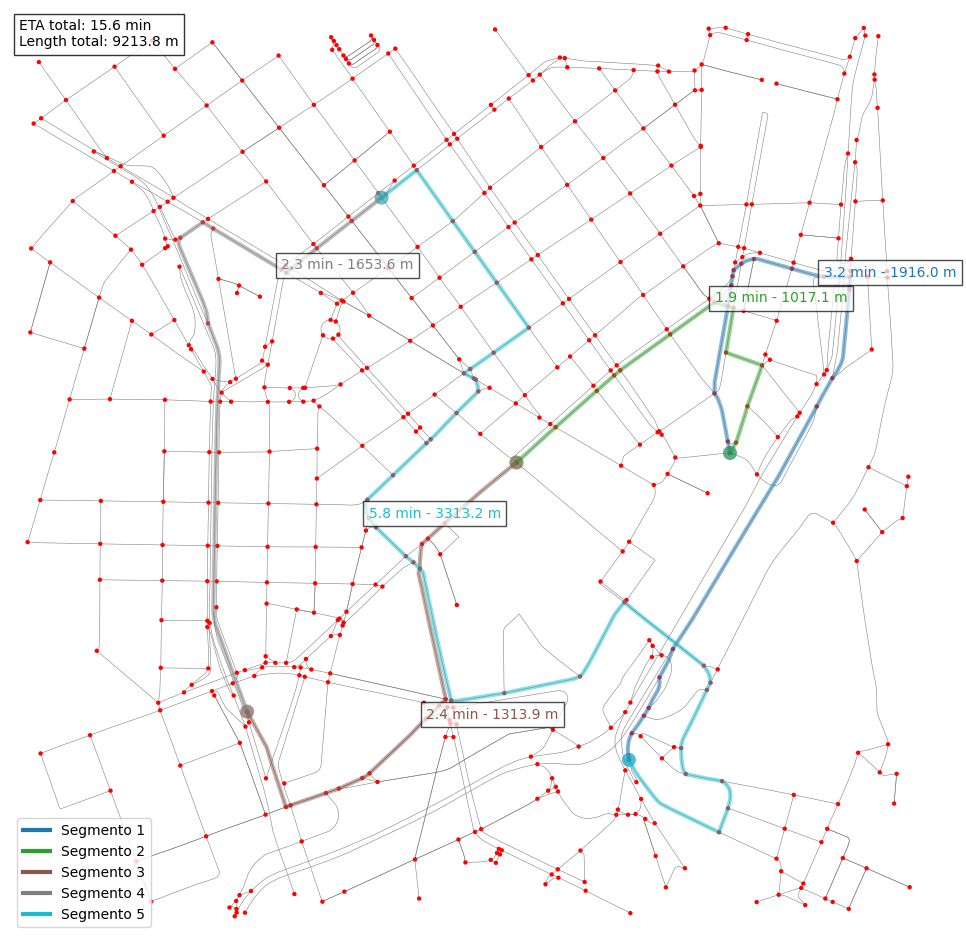

In [188]:
plot_route_with_eta(graph_proj, random_nodes, weight_function)

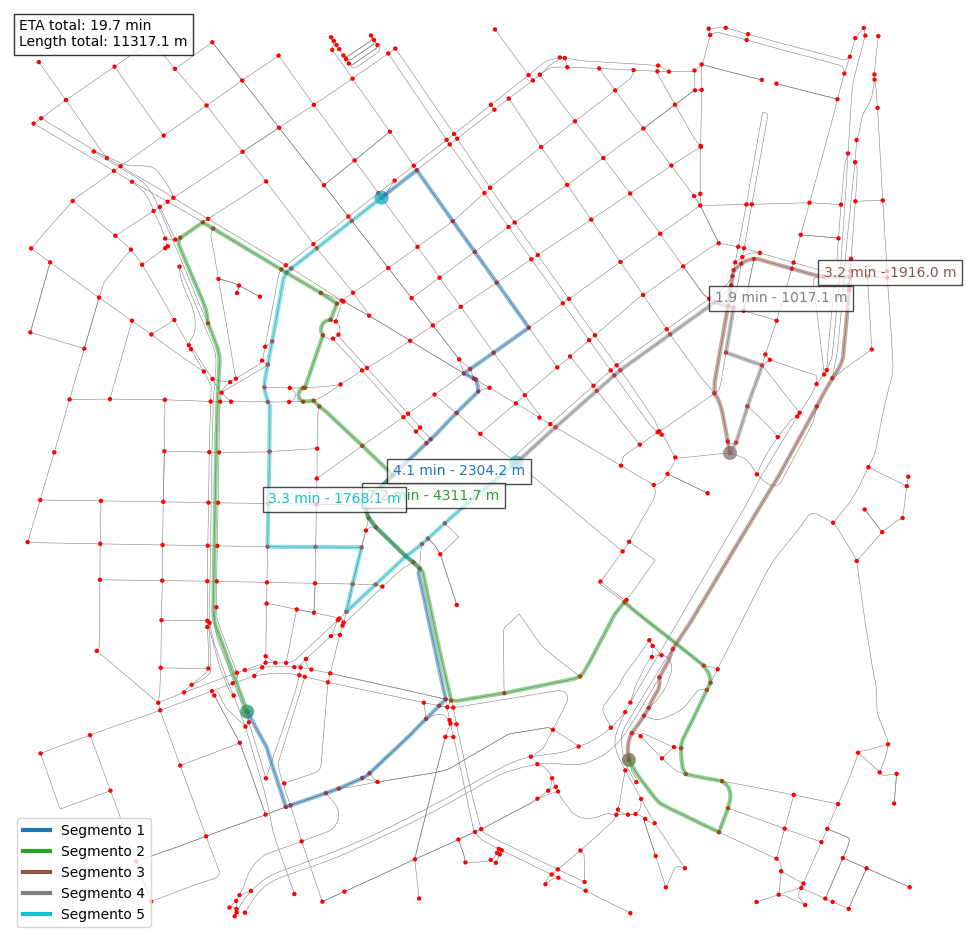

In [189]:
plot_route_with_eta(graph_proj, random.sample(random_nodes, len(random_nodes)), weight_function)

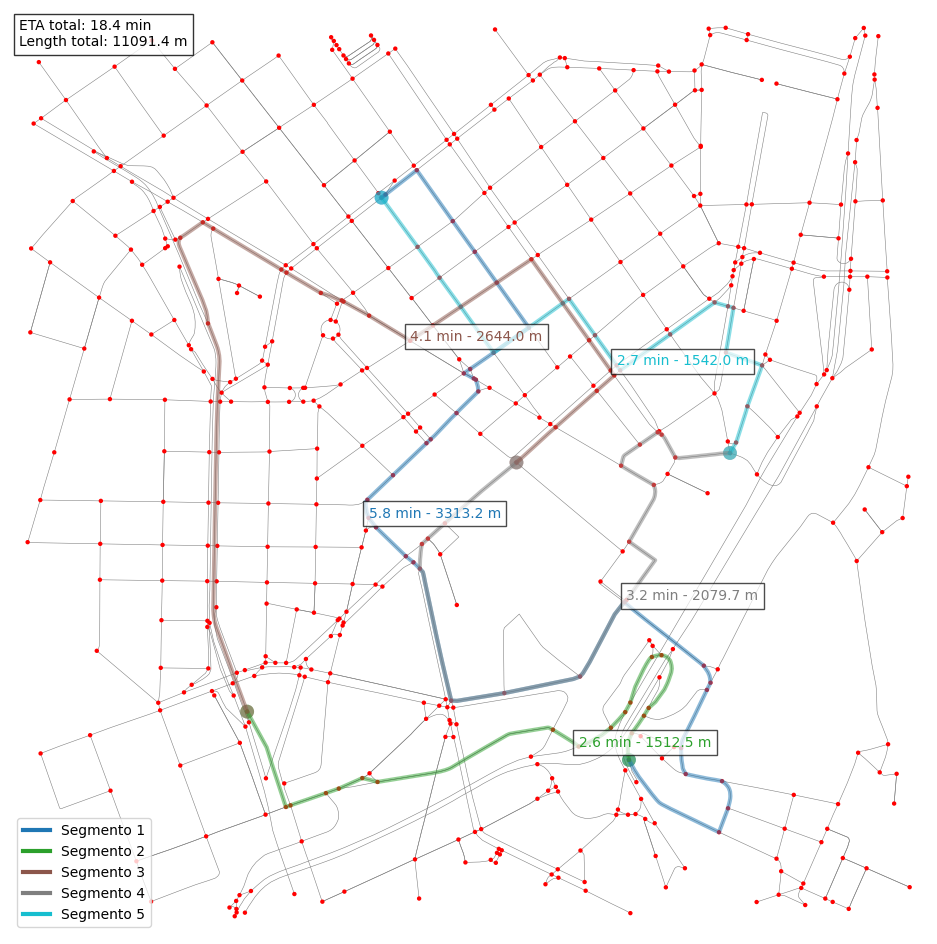

In [190]:
plot_route_with_eta(graph_proj, random.sample(random_nodes, len(random_nodes)), weight_function)